In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [3]:
url_ic = "https://huggingface.co/datasets/mehmetdavut/RubyCraft-3.4-Eval-Logs/resolve/main/ic_before_after.csv"
df = pd.read_csv(url_ic)

In [4]:
exp_mapping = {
    "exp-103": {"dataset": "1K", "quantization": "4-bit", "tier": "Small"},
    "exp-104": {"dataset": "5K", "quantization": "4-bit", "tier": "Small"},
    "exp-105": {"dataset": "1K", "quantization": "8-bit", "tier": "Small"},
    "exp-106": {"dataset": "5K", "quantization": "8-bit", "tier": "Small"},
    "exp-107": {"dataset": "1K", "quantization": "16-bit", "tier": "Small"},
    "exp-108": {"dataset": "5K", "quantization": "16-bit", "tier": "Small"},
    "exp-109": {"dataset": "1K", "quantization": "4-bit", "tier": "Big"},
    "exp-110": {"dataset": "5K", "quantization": "4-bit", "tier": "Big"},
    "exp-111": {"dataset": "1K", "quantization": "8-bit", "tier": "Big"},
    "exp-112": {"dataset": "5K", "quantization": "8-bit", "tier": "Big"},
    "exp-113": {"dataset": "1K", "quantization": "16-bit", "tier": "Big"},
    "exp-114": {"dataset": "5K", "quantization": "16-bit", "tier": "Big"},
}

exp_df = pd.DataFrame.from_dict(exp_mapping, orient="index").reset_index()
exp_df.rename(columns={"index": "experiment"}, inplace=True)
df_merged = pd.merge(df, exp_df, on="experiment", how="inner")

lora_df = df_merged[df_merged["model"].str.contains("lora")].copy()

In [5]:
def get_quality_label(model_name):
    if "high_quality" in model_name:
        return "High Quality (HQ) Subset"
    else:
        return "ALL Data Subset"


lora_df["data_quality"] = lora_df["model"].apply(get_quality_label)

lora_df["quantization"] = pd.Categorical(
    lora_df["quantization"], categories=["4-bit", "8-bit", "16-bit"], ordered=True
)

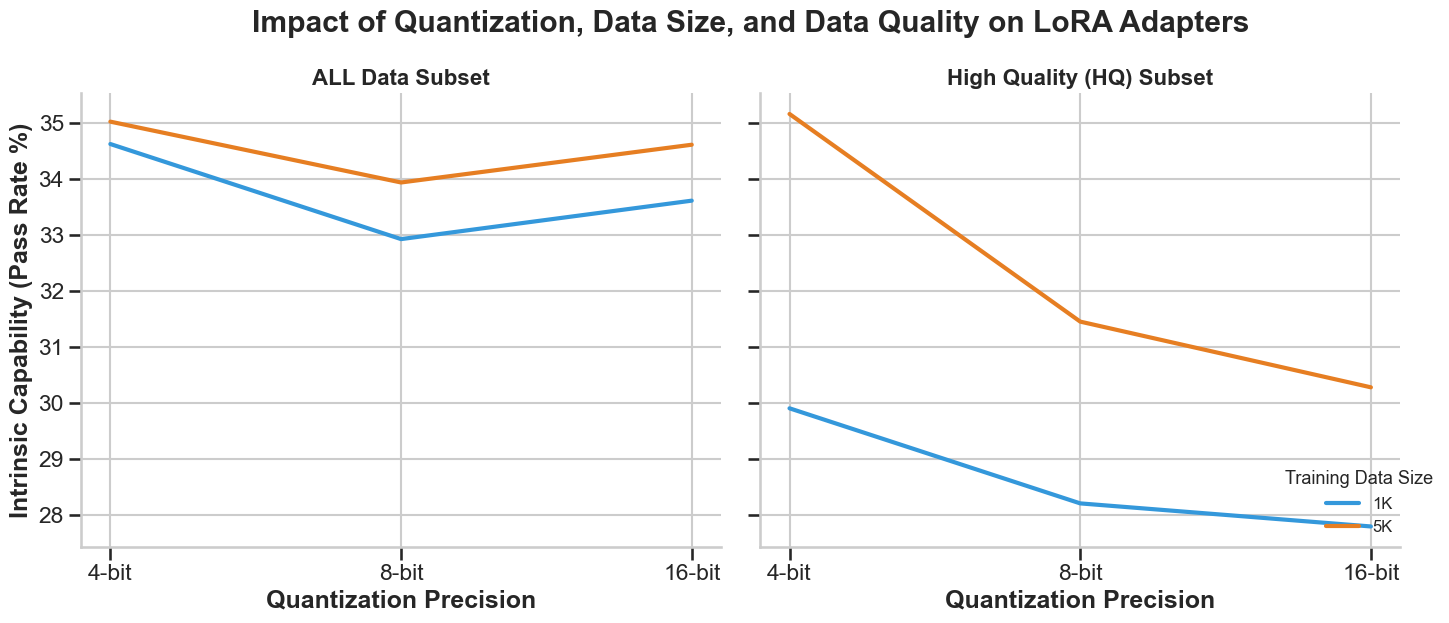

In [6]:
g = sns.relplot(
    data=lora_df,
    x="quantization",
    y="after_pct",
    hue="dataset",
    col="data_quality",  # Bu parametre iki ayrı grafik oluşturur!
    kind="line",
    markers=True,
    dashes=False,
    linewidth=3,
    markersize=12,
    palette=["#3498db", "#e67e22"],
    errorbar=None,
    height=6,
    aspect=1.2,
)

g.set_axis_labels(
    "Quantization Precision", "Intrinsic Capability (Pass Rate %)", fontweight="bold"
)
g.set_titles(col_template="{col_name}", fontweight="bold", size=16)
g.fig.suptitle(
    "Impact of Quantization, Data Size, and Data Quality on LoRA Adapters",
    fontweight="bold",
    y=1.05,
)

sns.move_legend(
    g,
    "lower right",
    bbox_to_anchor=(0.95, 0.15),
    title="Training Data Size",
    title_fontsize="13",
    fontsize="12",
)

In [7]:
import os

os.makedirs("../images", exist_ok=True)
g.savefig(
    "../images/quantization_scaling_quality_trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)